In [26]:
import numpy as np
import matplotlib.pyplot as plt

In [27]:
from sklearn import datasets
from sklearn.manifold import Isomap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

digits = datasets.load_digits()

In [28]:
digits.data.shape

(1797, 64)

fig, axes = plt.subplots(7,7, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

#np.random.seed(42)
#mychoices = np.random.choice(digits.images.shape[0],100)
mychoices = np.arange(100)

for i, ax in enumerate(axes.flat):
    ax.imshow((digits.images[mychoices[i]]), 
              cmap='binary')
    ax.text(0.05, 0.05, str(digits.target[mychoices[i]]),transform=ax.transAxes, color='green', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

In [29]:
X_transformed = Isomap(n_components=4).fit_transform(digits.data)

/opt/anaconda3/envs/astrostat/lib/python3.13/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/opt/anaconda3/envs/astrostat/lib/python3.13/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


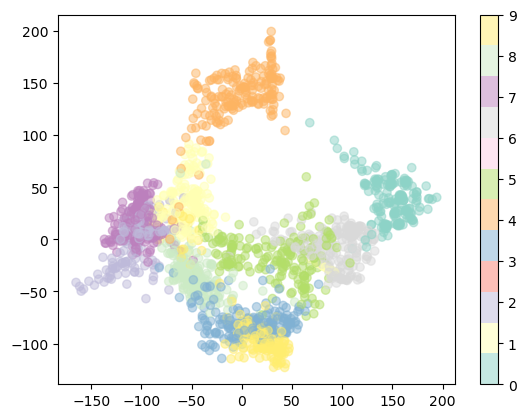

In [36]:
plt.scatter(X_transformed.T[0], X_transformed.T[1], c=digits.target, cmap=plt.colormaps['Set3'], alpha = 0.5)
plt.colorbar()

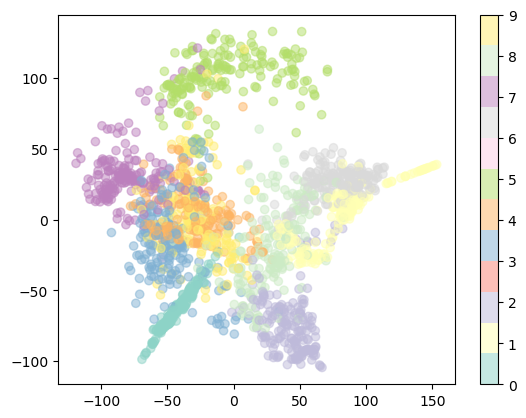

In [32]:
plt.scatter(X_transformed.T[2], X_transformed.T[3], c=digits.target, cmap=plt.colormaps['Set3'], alpha=0.5)
plt.colorbar()

In [21]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X_transformed, digits.target,test_size=0.2)

In [22]:
clf = LogisticRegression(solver='sag').fit(Xtrain, ytrain)

/opt/anaconda3/envs/astrostat/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [23]:
ypred = clf.predict(Xtrain)
print(accuracy_score(ytrain, ypred))
print(confusion_matrix(ytrain, ypred))

0.9109255393180237
[[150   0   0   0   0   0   0   0   0   0]
 [  0 125  10   0   0   0   8   0   0   0]
 [  0   5 132   0   0   0   0   0   4   0]
 [  0   0   0 122   0   2   0   1   5  12]
 [  0   0   0   0 137   0   0   0   0   1]
 [  0   1   0   0   1 149   1   0   0   2]
 [  0  11   0   0   0   0 130   0   0   0]
 [  0   0   0   0   0   0   0 144   0   3]
 [  0   5   9   4   0   0   0   1 116   3]
 [  0   0   1  15   1   3   0  17   2 104]]


In [24]:
ypred = clf.predict(Xtest)
print(accuracy_score(ytest, ypred))
print(confusion_matrix(ytest, ypred))
mat = confusion_matrix(ytest, ypred)

0.9027777777777778
[[28  0  0  0  0  0  0  0  0  0]
 [ 0 34  1  0  0  0  4  0  0  0]
 [ 0  0 34  0  0  0  0  1  1  0]
 [ 0  0  0 37  0  0  0  0  0  4]
 [ 0  0  0  0 42  1  0  0  0  0]
 [ 0  0  0  0  0 28  0  0  0  0]
 [ 0  4  0  0  0  1 35  0  0  0]
 [ 0  0  0  0  0  0  0 30  0  2]
 [ 0  0  1  0  0  0  0  2 32  1]
 [ 0  0  0  5  0  0  0  6  1 25]]
